## Notebook 7: AC Electricity Consumption, Downscaling

In [8]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [9]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [10]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [11]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [15]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path

# FUA / Regions paths 
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs 
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."
lut = (pd.read_csv(muni_lut_csv)
         .assign(muni_id=lambda d: d["muni_id"].astype(int))
         .sort_values("muni_id"))
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."
cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif"   # WBGT reference grid
mask_tif  = INT / "city_mask.tif"      # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
hot_npz_path = _first_existing(
    INT / f"wbgt_hot_days_2030_2100_{SLUG}.npz",
    INT / "wbgt_hot_days_2030_2100.npz",
    glob_pattern="wbgt_hot_days_2030_2100*.npz"
)
assert hot_npz_path and hot_npz_path.exists(), "Missing WBGT hot-days .npz (run NB3)."

npz = np.load(hot_npz_path)
YEARS = npz["years"].astype(int)        # (n_years,)
DATA  = npz["data"].astype("float32")   # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"Hot-days grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"
I2050 = DATA[list(YEARS).index(2050)]
print("Loaded hot-days:", hot_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage 
d = np.load(INT / "ac_coverage_maps.npz")
coverage_base   = d["coverage_base"].astype("float32")
coverage_policy = d["coverage_policy"].astype("float32")
CAP_MASK        = d["CAP_MASK"].astype(bool)
assert coverage_base.shape == (HGT, WDT)
assert coverage_policy.shape == (HGT, WDT)

# Population / CAP rasters 
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"),
               "15-64": d["a15_64"].astype("float32"),
               "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:  age["<15"]  = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s: age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:   age["65+"]  = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print("Loaded exposure:",
      f"\n  pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
      f"\n  age lt15:   {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
      f"\n  age 15-64:  {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
      f"\n  age 65+:    {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Vectors 
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni    = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref  = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print("Loaded:",
      "\n  FUA:", fua_gpkg.name,
      "\n  Regions:", regions_gpkg.name,
      "\n  muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
      "\n  CAPs:", cap_gpkg.name)

Using muni LUT: genova_muni_lut.csv | rows: 10
Using CAP LUT: genova_cap_lut.csv | rows: 70
Using CAP WGS84 LUT: genova_cap_wgs84_lut.csv
Loaded hot-days: wbgt_hot_days_2030_2100_genova.npz | years: 2030 → 2100
Loaded exposure: 
  pop_on_ref: (191, 291), sum=573935 
  age lt15:   (191, 291), sum=52792 
  age 15-64:  (191, 291), sum=333251 
  age 65+:    (191, 291), sum=187891
Loaded regions: 10 polygons; muni_on_ref shape: (191, 291)
Unique muni IDs on grid (>=0): 10
Loaded: 
  FUA: genova_fua.gpkg 
  Regions: genova_regions.gpkg 
  muni_on_ref: genova_muni_on_ref.tif (191, 291) 
  CAPs: genova_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [13]:
# AC NetCDF selection: AC electricity consumption (force SSP2/2050)
import xarray as xr, numpy as np, re
from shapely.geometry import box
from shapely.ops import transform as shp_transform
from pyproj import Transformer, CRS

ssp_choice, year_choice = 2, 2050  # SSP2 / 2050

nc_path = P(cfg.get("ac", {}).get("gridded_file", "ACgridded/ac_kWh_ssp1_ssp2_ssp3_ssp5_2010_2050.nc"))
assert nc_path.exists(), f"Missing {nc_path} — run Notebook 1 (Drive sync)."
ds = xr.open_dataset(nc_path, decode_times=False)

def pick_one(seq, options):
    for name in options:
        if name in seq: return name
    low = {s.lower(): s for s in seq}
    for name in options:
        if name.lower() in low: return low[name.lower()]
    return None

DIM_LAT  = pick_one(ds.dims,  ["latitude","lat","y"])
DIM_LON  = pick_one(ds.dims,  ["longitude","lon","x"])
DIM_SSP  = pick_one(ds.dims,  ["SSP","ssp","scenario"])
DIM_TIME = pick_one(ds.dims,  ["Time","time","year"])

def pick_var(ds):
    for v in ds.data_vars:
        hay = f"{v.lower()} " + " ".join(f"{k} {str(ds[v].attrs[k]).lower()}" for k in ds[v].attrs)
        if ("ac" in hay) and ("electric" in hay or "kwh" in hay):
            return v
    return list(ds.data_vars)[0]
VAR = pick_var(ds)

def decode_years(vals, units):
    vals = np.asarray(vals, dtype=float)
    if np.all((vals >= 1800) & (vals <= 2600)): return vals.astype(int)
    units = (units or "").lower()
    m = re.search(r"years\s+since\s+(\d{4})", units)
    return (int(m.group(1)) + vals).astype(int) if m else vals.astype(int)

# assign decoded years so selecting 2050 is exact
yrs = decode_years(ds[DIM_TIME].values, ds[DIM_TIME].attrs.get("units",""))
ds  = ds.assign_coords({DIM_TIME: yrs})

def select_label(vals, desired):
    vals_np = np.asarray(vals)
    if np.issubdtype(vals_np.dtype, np.number):
        return vals_np[int(np.argmin(np.abs(vals_np - float(desired))))]
    want = str(desired)
    for cand in [want, f"SSP{int(desired)}", f"ssp{int(desired)}", f"{int(desired)}"]:
        m = [v for v in vals if str(v).lower()==cand.lower()]
        if m: return m[0]
    return list(vals)[0]

ssp_label  = select_label(ds[DIM_SSP].values, ssp_choice)
year_label = select_label(ds[DIM_TIME].values, year_choice)

# mask fill values
da = ds[VAR]
for mv in [da.attrs.get("_FillValue"),
           da.encoding.get("_FillValue"),
           da.attrs.get("missing_value"),
           -999.0, -9999.0]:
    if mv is not None:
        da = da.where(da != mv)

sl = da.sel({DIM_SSP: ssp_label, DIM_TIME: year_label}).transpose(DIM_LAT, DIM_LON)

# choose the cell overlapping the FUA with max area (fallback: nearest finite)
from shapely.geometry import Polygon
def edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    step = float(np.mean(np.diff(centers))) if centers.size >= 2 else 0.0
    edge0 = centers[0] - 0.5 * step
    return edge0 + np.arange(centers.size + 1) * step

gseries = fua.to_crs("EPSG:4326").geometry
fua_ll = gseries.union_all() if hasattr(gseries, "union_all") else gseries.unary_union
lats = sl[DIM_LAT].values; lons = sl[DIM_LON].values
lat_edges = edges_from_centers(lats); lon_edges = edges_from_centers(lons)
to_ea = Transformer.from_crs("EPSG:4326", CRS.from_epsg(3035), always_xy=True).transform

best = None; best_area = 0.0
for i in range(len(lats)-1):
    for j in range(len(lons)-1):
        v = float(sl.values[i, j])
        if not np.isfinite(v): 
            continue
        cell = box(lon_edges[j], lat_edges[i], lon_edges[j+1], lat_edges[i+1])
        inter = cell.intersection(fua_ll)
        if inter.is_empty: 
            continue
        area = shp_transform(to_ea, inter).area
        if area > best_area:
            best_area = area
            best = (i, j, v)

if best is None:
    finite = np.isfinite(sl.values)
    ii, jj = np.where(finite)
    cy, cx = fua_ll.centroid.y, fua_ll.centroid.x
    k = int(np.argmin((ii - np.argmin(np.abs(lats - cy)))**2 +
                      (jj - np.argmin(np.abs(lons - cx)))**2))
    i, j = int(ii[k]), int(jj[k]); per_user_city = float(sl.values[i, j]); method = "nearest_non_nan"
else:
    i, j, per_user_city = best; method = "max_overlap"

print(f"AC per-AC-user (kWh/user/yr): {per_user_city:.6f}  (SSP{ssp_choice}, {year_choice}, {method})")

AC per-AC-user (kWh/user/yr): 464.019531  (SSP2, 2050, max_overlap)


Missing values as -999

Before I was using a completely other technique where I was reprojecting the raster to our ref grid and aggregating over the city. But since it's one pixel for Rome I tried to intersect and find the Rome pixel. 

**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [16]:
import numpy as np
import pandas as pd

assert 'per_user_city' in globals() and np.isfinite(per_user_city), \
    "per_user_city must be defined by the NetCDF/FUA selection cell."

# grids / aliases
coverage_map = coverage_base
pop_grid     = pop_on_ref
cap_ids      = cap_on_ref

# citywide AC share from the coverage map (population-weighted on CITY_MASK)
m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
ac_city = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))
print(f"AC share from map (city pop-weighted): {ac_city:.3f}")

# CAP-level hazard index for dispersion 
CAP_PIX = CITY_MASK & np.isfinite(I2050) & (cap_ids > 0)
valid   = CAP_PIX & np.isfinite(pop_grid)

dfH = pd.DataFrame({
    "cap_id": cap_ids[valid].ravel().astype(int),
    "pop":    pop_grid[valid].ravel().astype(float),
    "H":      I2050[valid].ravel().astype(float),
})

def _wavg_pop(g):
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_H  = dfH.groupby("cap_id").apply(_wavg_pop).reset_index(name="H_cap")
H_city = float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean())

# drawing per-user consumption per CAP (Normal around city mean and sigma scales with heat) 
rng    = np.random.default_rng(42)   # reproducible
sigma0 = 0.20                        # coefficient of variation at H_cap == H_city
gamma  = 1.0                         # elasticity of dispersion to hazard

cap_draws = cap_H.copy()
ratio     = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0)
sigma_cap = sigma0 * (ratio ** gamma) * float(per_user_city)

mu    = np.full_like(sigma_cap, float(per_user_city), dtype=float)
draws = rng.normal(loc=mu, scale=sigma_cap)
draws = np.clip(draws, 0.0, np.inf)  # no negatives
cap_draws["per_user_CAP_raw"] = draws.astype("float32")

# painting to grid 
lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

# converting to per-capita and totals, match city target exactly
kwh_pc_raw  = per_user_map * coverage_map                 # kWh per capita (overall)
kwh_tot_raw = kwh_pc_raw * pop_grid                       # kWh totals

# scaling so that the users-weighted per-user mean equals per_user_city
w_users = (coverage_map * pop_grid) * CITY_MASK
k = float(per_user_city) / (np.nansum(per_user_map * w_users) / np.nansum(w_users))
per_user_map *= k

kwh_pc_map  = per_user_map * coverage_map
kwh_tot_map = kwh_pc_map  * pop_grid

# CAP table of per-user means after scaling 
cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
cap_per_user = cap_draws[["cap_id","per_user_CAP"]].rename(columns={"per_user_CAP": "kwh_per_user_cap"})

# diagnostics 
per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users))
ac_share_from_map  = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
city_total_gwh     = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)

print("Per-user mean (city):", per_user_mean_city)
print("AC share from map:   ", ac_share_from_map)
print("City total GWh:      ", city_total_gwh)

# aggregating by CAP for reporting / CBA 
dfE = pd.DataFrame({
    "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
    "pop":    pop_grid[CITY_MASK].ravel().astype(float),
    "kwh":    kwh_tot_map[CITY_MASK].ravel().astype(float),
})
dfE = dfE[dfE["cap_id"] > 0]

cap_energy = (dfE.groupby("cap_id")
                .agg(pop_cap=("pop","sum"),
                     kwh_cap=("kwh","sum"))
                .reset_index())
cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

AC share from map (city pop-weighted): 0.647
Per-user mean (city): 464.0195617675781
AC share from map:    0.6461209058761597
City total GWh:       172.072992


**CAP Maps or tables:**

City pop: 572,725
City AC users: 370,831  (AC share ≈ 0.647)
City total AC electricity: 172.073 GWh/yr
City per-AC-user mean (users-weighted): 464.019533 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall)


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,29,0.899580,578.334106,5100.867546,2.653766e+06,520.257691
1,34,0.837583,556.021606,8189.392120,3.813915e+06,465.714022
2,26,0.827378,553.044922,11480.953613,5.253426e+06,457.577454
3,32,0.907350,499.876892,11486.423634,5.209821e+06,453.563386
4,67,0.892660,504.843475,9485.408793,4.274633e+06,450.653533
5,50,0.867788,515.167419,19345.958483,8.648733e+06,447.056305
6,66,0.854854,482.075195,6510.368746,2.682947e+06,412.103728
7,56,0.774989,526.717163,9447.184104,3.856342e+06,408.200134
8,57,0.799286,498.220520,8006.309411,3.188278e+06,398.220674
9,27,0.730523,540.876648,3813.634056,1.506854e+06,395.122804


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall)


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,53,0.368905,380.269775,24684.488758,3.462823e+06,140.283340
1,58,0.433613,393.466156,25692.182121,4.383395e+06,170.611999
2,61,0.353164,483.619019,10942.317908,1.868913e+06,170.796845
3,52,0.385435,445.764282,11545.353348,1.983644e+06,171.813171
4,60,0.398600,468.831299,16535.252707,3.090047e+06,186.876312
5,37,0.494190,393.283051,7556.156555,1.468588e+06,194.356522
6,41,0.471682,433.823273,17040.709773,3.486984e+06,204.626694
7,42,0.409821,513.196228,6909.012202,1.453095e+06,210.318787
8,54,0.570969,381.851074,20389.707881,4.445472e+06,218.025299
9,43,0.485390,484.727295,8928.469820,2.100708e+06,235.282013



Top 10 CAPs by kwh_cap — Total kWh


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,55,0.653291,527.391174,26507.204988,9.132789e+06,344.539856
1,50,0.867788,515.167419,19345.958483,8.648733e+06,447.056305
2,47,0.922525,413.580109,21591.630489,8.238026e+06,381.537933
3,51,0.512242,577.665588,25857.373116,7.651320e+06,295.904755
4,48,0.939425,403.901154,16426.107170,6.232637e+06,379.434846
5,45,0.628133,501.538361,17351.322166,5.466233e+06,315.032622
6,35,0.703571,454.302551,17070.802522,5.456411e+06,319.634125
7,26,0.827378,553.044922,11480.953613,5.253426e+06,457.577454
8,32,0.907350,499.876892,11486.423634,5.209821e+06,453.563386
9,49,0.812511,369.256378,16787.025036,5.036526e+06,300.024932


Bottom 10 CAPs by kwh_cap — Total kWh


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,1,0.732671,465.496704,6.163891,2.102232e+03,341.056029
1,11,0.737996,461.441711,6.596672,2.246445e+03,340.542168
2,5,0.751857,475.715393,26.791318,9.582455e+03,357.670164
3,12,0.736217,449.220306,556.001873,1.838830e+05,330.723755
4,14,0.737261,458.125702,1304.443549,4.405865e+05,337.758178
5,9,0.750433,371.334869,2532.605384,7.057408e+05,278.661987
6,7,0.734291,389.697479,2875.874240,8.229348e+05,286.151186
7,38,0.715125,552.505859,3284.161095,1.297607e+06,395.110626
8,42,0.409821,513.196228,6909.012202,1.453095e+06,210.318787
9,37,0.494190,393.283051,7556.156555,1.468588e+06,194.356522


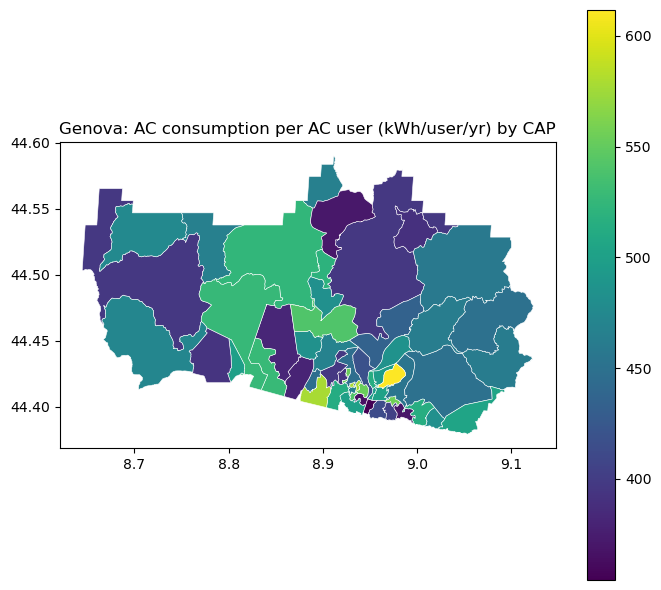

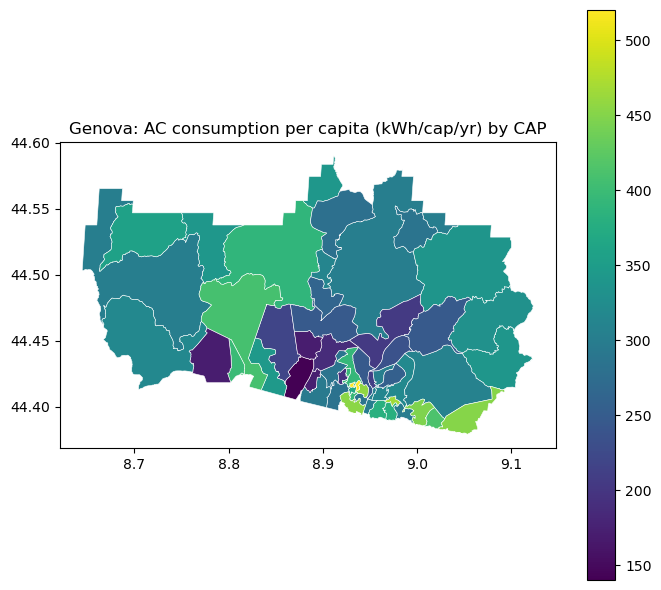

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_map.geojson


In [17]:
# CAP-level consumption tables and maps 
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

coverage_map = coverage_base
pop_grid     = pop_on_ref
cap_ids      = cap_on_ref

# matched pixel universe: within city, with CAP, and finite for all needed layers
CAP_PIX = (CITY_MASK &
           (cap_ids > 0) &
           np.isfinite(pop_grid) &
           np.isfinite(coverage_map) &
           np.isfinite(kwh_tot_map))

# users and pop by CAP
df_cap_base = pd.DataFrame({
    "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
    "pop":    pop_grid[CAP_PIX].ravel().astype(float),
    "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
})
cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                 .agg(pop_cap=("pop","sum"),
                      users_cap=("users","sum")))
cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0,
                                         cap_pop_users["users_cap"] / cap_pop_users["pop_cap"],
                                         np.nan)

# energy totals by CAP (sum of pixel kWh)
df_kwh = pd.DataFrame({
    "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
    "kwh":    kwh_tot_map[CAP_PIX].ravel().astype(float),
})
cap_energy = (df_kwh.groupby("cap_id", as_index=False)
              .agg(kwh_cap=("kwh","sum")))

# per-AC-user (from earlier scaling step)
# -> cap_per_user must exist: columns ['cap_id','kwh_per_user_cap']

# merging to one CAP table + overall per-capita
cap_tbl = (cap_pop_users
           .merge(cap_energy, on="cap_id", how="left")
           .merge(cap_per_user, on="cap_id", how="left"))
cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0,
                                     cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)

# city checks on the same matched universe
city_pop     = float(np.nansum(pop_grid[CAP_PIX]))
city_users   = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
per_user_mean_city = float(
    np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
)

print(f"City pop: {city_pop:,.0f}")
print(f"City AC users: {city_users:,.0f}  (AC share ≈ {city_users/city_pop:.3f})")
print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

# ranks (if needed)
def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

show_rank(cap_tbl, "kwh_pc_overall", k=10, title="kWh per capita (overall)")
show_rank(cap_tbl, "kwh_cap",        k=10, title="Total kWh")

# joining to CAP polygons (cap_4326 loaded earlier)
cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")

# maps
fig, ax = plt.subplots(1, 1, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_per_user_cap",
                                 legend=True, linewidth=0.4, edgecolor="white")
ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_pc_overall",
                                 legend=True, linewidth=0.4, edgecolor="white")
ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP")
plt.tight_layout(); plt.show()

# save 
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)
cap_tbl_out = cap_tbl.copy()
cap_tbl_out["kwh_GWh"] = cap_tbl_out["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_out.to_csv(cap_tbl_csv, index=False)

cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map.to_crs("EPSG:4326")[["cap_id","geometry","kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
        .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

**So super nice because now the City total AC electricity: 1214.216 GWh/yr is just City AC users multiplied by City per-AC-user mean (our pixel value)!**

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**

In [18]:
# Municipio-level AC electricity: per-user, per-capita, totals (city-agnostic) 
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

coverage_map = coverage_base
pop_grid     = pop_on_ref

# sanity
assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."

def city_diag(mask, label):
    users = float(np.nansum((coverage_map * pop_grid)[mask]))
    per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
    kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
    pop = float(np.nansum(pop_grid[mask]))
    print(f"[{label}] per-user={per_user:.6f}  AC-share={users/pop:.3f}  total={kwh:.3f} GWh  pop={pop:,.0f}  users={users:,.0f}")
    return per_user, users, kwh

# universes (keep id==0 as "outside" bucket)
mask_all = CITY_MASK
mask_in  = CITY_MASK & (muni_on_ref > 0)
mask_out = CITY_MASK & (muni_on_ref == 0)

print("City diagnostics by universe:")
pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
pu_in,  u_in,  k_in  = city_diag(mask_in,  "Municipi-only (muni_on_ref>0)")
pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

print("\nCheck: in + out should equal all")
print("users:", u_in + u_out, "vs", u_all)
print("GWh:  ", k_in + k_out, "vs", k_all)

City diagnostics by universe:
[ALL FUA] per-user=464.019508  AC-share=0.646  total=172.073 GWh  pop=573,935  users=370,831
[Municipi-only (muni_on_ref>0)] per-user=466.027499  AC-share=0.641  total=160.654 GWh  pop=537,810  users=344,730
[Outside Municipi (muni_id==0)] per-user=437.499956  AC-share=0.723  total=11.419 GWh  pop=36,125  users=26,101

Check: in + out should equal all
users: 370831.3671875 vs 370831.375
GWh:   172.073004 vs 172.072992



From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 464.0195504322527
City total GWh: 172.0730012174683

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall)


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,2,0.788772,484.073646,66985.117187,2.557652e+07,381.823851
1,4,0.815702,463.248057,66863.920045,2.526601e+07,377.872154
2,6,0.868104,424.517373,69809.518960,2.572656e+07,368.525153
3,1,0.580268,501.394944,46681.691490,1.358172e+07,290.943222
4,8,0.590321,461.280514,50785.608834,1.382910e+07,272.303602
5,3,0.526044,506.765249,51870.632425,1.382772e+07,266.580871
6,7,0.535904,449.045371,70436.151072,1.695012e+07,240.645201
7,5,0.511196,451.403091,54418.558059,1.255738e+07,230.755405
8,9,0.449118,497.120034,59742.616482,1.333848e+07,223.265713


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall)


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,9,0.449118,497.120034,59742.616482,1.333848e+07,223.265713
1,5,0.511196,451.403091,54418.558059,1.255738e+07,230.755405
2,7,0.535904,449.045371,70436.151072,1.695012e+07,240.645201
3,3,0.526044,506.765249,51870.632425,1.382772e+07,266.580871
4,8,0.590321,461.280514,50785.608834,1.382910e+07,272.303602
5,1,0.580268,501.394944,46681.691490,1.358172e+07,290.943222
6,6,0.868104,424.517373,69809.518960,2.572656e+07,368.525153
7,4,0.815702,463.248057,66863.920045,2.526601e+07,377.872154
8,2,0.788772,484.073646,66985.117187,2.557652e+07,381.823851



Top 10 Municipi by kwh_muni — Total kWh


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,6,0.868104,424.517373,69809.518960,2.572656e+07,368.525153
1,2,0.788772,484.073646,66985.117187,2.557652e+07,381.823851
2,4,0.815702,463.248057,66863.920045,2.526601e+07,377.872154
3,7,0.535904,449.045371,70436.151072,1.695012e+07,240.645201
4,8,0.590321,461.280514,50785.608834,1.382910e+07,272.303602
5,3,0.526044,506.765249,51870.632425,1.382772e+07,266.580871
6,1,0.580268,501.394944,46681.691490,1.358172e+07,290.943222
7,9,0.449118,497.120034,59742.616482,1.333848e+07,223.265713
8,5,0.511196,451.403091,54418.558059,1.255738e+07,230.755405


Bottom 10 Municipi by kwh_muni — Total kWh


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,5,0.511196,451.403091,54418.558059,1.255738e+07,230.755405
1,9,0.449118,497.120034,59742.616482,1.333848e+07,223.265713
2,1,0.580268,501.394944,46681.691490,1.358172e+07,290.943222
3,3,0.526044,506.765249,51870.632425,1.382772e+07,266.580871
4,8,0.590321,461.280514,50785.608834,1.382910e+07,272.303602
5,7,0.535904,449.045371,70436.151072,1.695012e+07,240.645201
6,4,0.815702,463.248057,66863.920045,2.526601e+07,377.872154
7,2,0.788772,484.073646,66985.117187,2.557652e+07,381.823851
8,6,0.868104,424.517373,69809.518960,2.572656e+07,368.525153


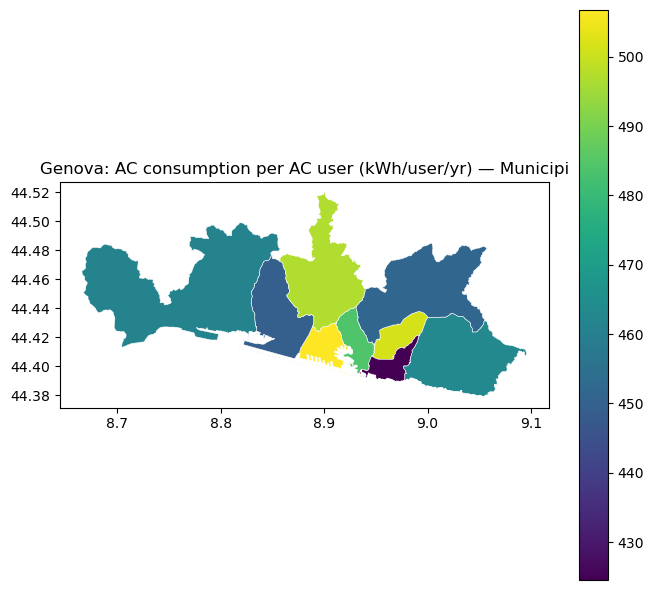

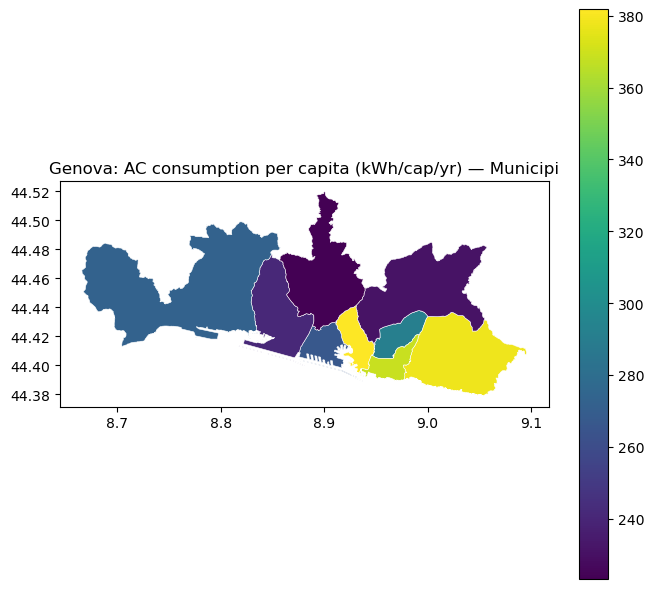

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_map.geojson


In [19]:
# Municipi AC electricity: per-user, per-capita, totals 
# Build pixel to Municipio table over the full city mask (includes muni_id==0) 
valid_all = (CITY_MASK &
             np.isfinite(per_user_map) &
             np.isfinite(kwh_tot_map) &
             np.isfinite(pop_grid) &
             np.isfinite(coverage_map))

df = pd.DataFrame({
    "muni_id":  muni_on_ref[valid_all].ravel().astype(int),           # includes 0
    "pop":      pop_grid[valid_all].ravel().astype(float),
    "users":   (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
    "kwh":      kwh_tot_map[valid_all].ravel().astype(float),
    "per_user": per_user_map[valid_all].ravel().astype(float),
})

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

# users-weighted per-user by municipio
per_user_by_muni = (df.groupby("muni_id")
                      .apply(lambda g: _wavg(g["per_user"], g["users"]))
                      .reset_index(name="kwh_per_user_muni"))

# totals by municipio
muni_tbl_all = (df.groupby("muni_id", as_index=False)
                  .agg(pop_muni=("pop","sum"),
                       users_muni=("users","sum"),
                       kwh_muni=("kwh","sum"))
                  .merge(per_user_by_muni, on="muni_id", how="left"))

# rates
muni_tbl_all["ac_share_muni"]  = np.where(muni_tbl_all["pop_muni"] > 0,
                                          muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0,
                                          muni_tbl_all["kwh_muni"]  / muni_tbl_all["pop_muni"], np.nan)

# city diagnostics recomputed from the grouped table (should match the pixel-level check)
users_sum = float(muni_tbl_all["users_muni"].sum())
per_user_from_groups = float(np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"])
                             / max(users_sum, 1e-12))
kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
print("\nFrom groupby (includes muni_id=0):")
print("Users-weighted per-user mean (city):", per_user_from_groups)
print("City total GWh:", kwh_sum)

# tables and maps for Municipi only (exclude id==0 for reporting) 
muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()

def show_rank(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni","pop_muni","kwh_muni","kwh_pc_overall"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

show_rank(muni_only, "kwh_pc_overall", k=10, title="kWh per capita (overall)")
show_rank(muni_only, "kwh_muni",       k=10, title="Total kWh")

# map join 
muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns
            else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")

fig, ax = plt.subplots(1,1, figsize=(7,6))
muni_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_per_user_muni",
                                  legend=True, linewidth=0.4, edgecolor="white")
ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(7,6))
muni_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_pc_overall",
                                  legend=True, linewidth=0.4, edgecolor="white")
ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi")
plt.tight_layout(); plt.show()

# outputs to city folder
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"

(muni_tbl_all.assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
             .to_csv(muni_csv, index=False))

muni_map.to_crs("EPSG:4326")[["muni_id","geometry","kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]] \
        .to_file(muni_geo, driver="GeoJSON")

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the maps per AC user and per capita look different? Because the denominator is not the same. Per-AC_user varies because we draw CAP-level kWh/user around the city mean and scale it to match the city target. The map reflects only usage among households that have AC while the per-capita divides this same energy across everyone in the CAP. It equals AC share*per-AC-user. So places with low ownership look much lower per-capita even if users there consume a lot. Conversely, places with high ownership look high even if users don't consume unusually much. Finally, about the Municipi vs CAP, municipio values are population-weighted aggregates of the CAPs inside them. Rankings of totals differ because total kWh = per-capita * population. 
</blockquote>